In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate

df = pd.read_csv('SeoulBikeData.csv')
df = df.drop(columns=df.select_dtypes(include=object))

X = df.drop(columns='Rented Bike Count')
Y = df['Rented Bike Count']

Definindo $\lambda$ (Embora haja bibliotecas prontas para definir o parâmetro, resolvi definir manualmente a primeira vez por fins didáticos)

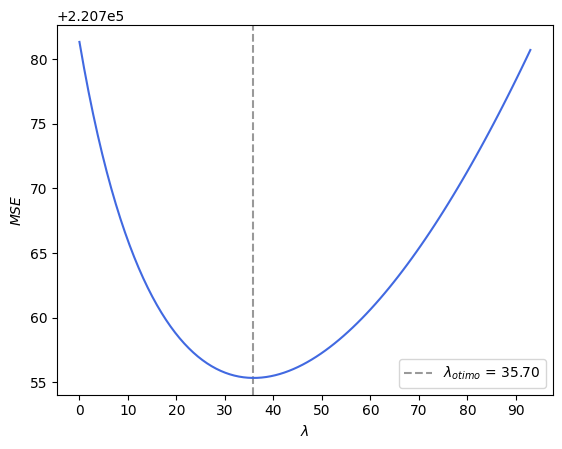

In [2]:
lamb = np.linspace(0,93,100)

erros = []

for i in range(len(lamb)):

    model = Pipeline([
        ('scaler',StandardScaler()),
        ('ridge',Ridge(alpha=lamb[i]))
    ])

    cv = KFold(n_splits=10,shuffle=True,random_state=0)

    mse = cross_validate(model,X,Y,cv=cv,scoring='neg_mean_squared_error')

    erros.append(-mse['test_score'].mean())

lamb_opm = lamb[np.argmin(erros)]

plt.figure()
plt.axvline(x=lamb_opm,ls='--',color='black',alpha=0.4, label = rf'$\lambda_{{otimo}}$ = {lamb_opm:.2f}')
plt.plot(lamb,erros,color='royalblue')
plt.ylabel(r'$MSE$')
plt.xlabel(r'$\lambda$')
plt.xticks(np.arange(0,91,10))
plt.legend()
plt.show()

In [3]:
model = Pipeline([
    ('norm',StandardScaler()),
    ('ridge',Ridge(alpha=lamb_opm))
])

cv = KFold(n_splits=10,shuffle=True,random_state=1)

results = cross_validate(model,X,Y,cv=cv,
                         scoring={'MSE':'neg_mean_squared_error',
                                  'RMSE':'neg_root_mean_squared_error',
                                  'MAE':'neg_mean_absolute_error',
                                  'R2':'r2'})

rmse = -results['test_RMSE']
r2 = results['test_R2']

print('Resultado via Ridge Regression:')
print(f'RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}')
print(f'R²:   {r2.mean():.4f} ± {r2.std():.4f}')


### COMPARANDO COM LEAST SQUARES


model = Pipeline([
    #('norm',StandardScaler()),
    ('OLS',LinearRegression())
])

cv = KFold(n_splits=10,shuffle=True,random_state=1)

results = cross_validate(model,X,Y,cv=cv,
                         scoring={'MSE':'neg_mean_squared_error',
                                  'RMSE':'neg_root_mean_squared_error',
                                  'MAE':'neg_mean_absolute_error',
                                  'R2':'r2'})

rmse = -results['test_RMSE']
r2 = results['test_R2']

print('\nResultado via Linear Regression:')
print(f'RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}')
print(f'R²:   {r2.mean():.4f} ± {r2.std():.4f}')

Resultado via Ridge Regression:
RMSE: 469.5863 ± 15.9819
R²:   0.4693 ± 0.0159

Resultado via Linear Regression:
RMSE: 469.6398 ± 15.9569
R²:   0.4692 ± 0.0158


In [4]:
ols = LinearRegression()
ridge = Ridge(alpha=lamb_opm)

ols.fit(X, Y)
ridge.fit(X, Y)

for feature, b_ols, b_ridge in zip(X.columns,
                                    ols.coef_,
                                    ridge.coef_):

    print(f'{feature:20s} '
          f'OLS = {b_ols:10.4f}   '
          f'Ridge = {b_ridge:10.4f}')

Hour                 OLS =    27.3155   Ridge =    27.3259
Temperature(C)       OLS =    26.5793   Ridge =    26.4032
Humidity(%)          OLS =    -8.8115   Ridge =    -8.8274
Wind speed (m/s)     OLS =     6.9221   Ridge =     6.7495
Visibility (10m)     OLS =     0.0213   Ridge =     0.0215
Dew point temperature(C) OLS =     5.4131   Ridge =     5.5620
Solar Radiation (MJ/m2) OLS =   -79.3428   Ridge =   -78.4178
Rainfall(mm)         OLS =   -58.8069   Ridge =   -58.6003
Snowfall (cm)        OLS =    21.0770   Ridge =    20.5125


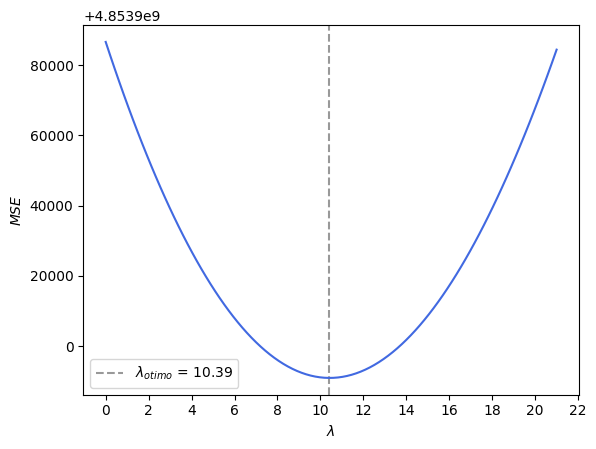

In [5]:
df = pd.read_csv('housing.csv') 
df = df.drop(columns=df.select_dtypes(include=object))
df = df.dropna()

X = df.drop(columns='median_house_value')
Y = df['median_house_value']

lamb = np.linspace(0,21,100)

erros = []

for i in range(len(lamb)):

    model = Pipeline([
        ('scaler',StandardScaler()),
        ('ridge',Ridge(alpha=lamb[i]))
    ])

    cv = KFold(n_splits=10,shuffle=True,random_state=0)

    mse = cross_validate(model,X,Y,cv=cv,scoring='neg_mean_squared_error')

    erros.append(-mse['test_score'].mean())

lamb_opm = lamb[np.argmin(erros)]

plt.figure()
plt.axvline(x=lamb_opm,ls='--',color='black',alpha=0.4, label = rf'$\lambda_{{otimo}}$ = {lamb_opm:.2f}')
plt.plot(lamb,erros,color='royalblue')
plt.ylabel(r'$MSE$')
plt.xlabel(r'$\lambda$')
plt.xticks(np.arange(0,23,2))
plt.legend()
plt.show()

In [6]:
model = Pipeline([
    ('norm',StandardScaler()),
    ('ridge',Ridge(alpha=lamb_opm))
])

cv = KFold(n_splits=10,shuffle=True,random_state=1)

results = cross_validate(model,X,Y,cv=cv,
                         scoring={'MSE':'neg_mean_squared_error',
                                  'RMSE':'neg_root_mean_squared_error',
                                  'MAE':'neg_mean_absolute_error',
                                  'R2':'r2'})

rmse = -results['test_RMSE']
r2 = results['test_R2']

print('Resultado via Ridge Regression:')
print(f'RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}')
print(f'R²:   {r2.mean():.4f} ± {r2.std():.4f}')


### COMPARANDO COM LEAST SQUARES


model = Pipeline([
    ('norm',StandardScaler()),
    ('OLS',LinearRegression())
])

cv = KFold(n_splits=10,shuffle=True,random_state=1)

results = cross_validate(model,X,Y,cv=cv,
                         scoring={'MSE':'neg_mean_squared_error',
                                  'RMSE':'neg_root_mean_squared_error',
                                  'MAE':'neg_mean_absolute_error',
                                  'R2':'r2'})

rmse = -results['test_RMSE']
r2 = results['test_R2']

print('\nResultado via Linear Regression:')
print(f'RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}')
print(f'R²:   {r2.mean():.4f} ± {r2.std():.4f}')

Resultado via Ridge Regression:
RMSE: 69649.1461 ± 1544.3756
R²:   0.6351 ± 0.0194

Resultado via Linear Regression:
RMSE: 69649.4496 ± 1549.8420
R²:   0.6351 ± 0.0195
